In [5]:
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, confusion_matrix
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib as mpl
from matplotlib import font_manager
import math
import lightgbm as lgb
import numpy as np

pd.set_option('display.max_columns', None)
data_path = '/data/home/yansn/naojiye/data/final_data/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)
filtered_df.shape

(887, 232)

In [6]:
filtered_df = filtered_df[['Unnamed: 0', 'patientId','脑脊液_有核细胞计数_定量', '脑脊液_葡萄糖_定量','血_嗜酸性粒细胞百分比_定量','血_降钙素原_定量','血_乙型肝炎病毒核心抗体.IgM_定量', '分组', '组名']]

In [7]:
import re
# 替换特征名中的 [，]
def clean_feature_names_simple(feature_names):
    cleaned_names = []
    for name in feature_names:
        cleaned_name = name.replace('[', '').replace(']', '').replace('<', '').replace('>', '').replace('.', '').replace('(', '').replace(')', '').replace(':', '').replace(',', '').replace('"', '').replace('\\', '')
        cleaned_names.append(cleaned_name)
    return cleaned_names


# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)
# filtered_df.columns = [clean_feature_names_simple(col) for col in filtered_df.columns]
print("清洗后的列名:", filtered_df.columns.tolist())

清洗后的列名: ['Unnamed 0', 'patientId', '脑脊液_有核细胞计数_定量', '脑脊液_葡萄糖_定量', '血_嗜酸性粒细胞百分比_定量', '血_降钙素原_定量', '血_乙型肝炎病毒核心抗体IgM_定量', '分组', '组名']


In [8]:
# 区分是否是脑膜炎：0是一类，1~6是一类

# 1. 数据预处理：将 'gender' 列转换为数值型
# filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})

# 去除病毒性脑炎（8）病状
filtered_df = filtered_df[filtered_df['分组']!=8]

# 选择特征 将数据正例和反例平均分配
filter_1 = filtered_df[filtered_df["分组"]==0]
filter_2= filtered_df[filtered_df["分组"].isin([1,2,3,4,5,6])]

X_1 = filter_1[list(filter_1.columns)[2:-2]]
X_2 = filter_2[list(filter_2.columns)[2:-2]]

# 标签（分组，1 类与其他类）
y_1 = (filter_1['分组'] == 0).astype(int) # 如果分组为 0，标签为 1，否则为 0
y_2 = (filter_2['分组'] == 0).astype(int) 

# 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

# 将正例与反例拼接
X_train = pd.concat([X_train_1,X_train_2])
y_train = pd.concat([y_train_1,y_train_2])

X_val = pd.concat([X_val_1,X_val_2])
y_val = pd.concat([y_val_1,y_val_2])

X_test = pd.concat([X_test_1,X_test_2])
y_test = pd.concat([y_test_1,y_test_2])

# 创建 LightGBM 数据集（可以提高训练效率）
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# 定义 Optuna 目标函数
def objective(trial):
    # 建议超参数范围
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300, step=10),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'random_state': 42
    }
    
    # 添加类别权重处理不平衡数据（可选）
    if trial.suggest_categorical('use_scale_pos_weight', [True, False]):
        scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
        params['scale_pos_weight'] = scale_pos_weight
    
    # 训练模型
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)],  # 早停防止过拟合
        # verbose=False
        # verbose = 1,
    )
    
    # 预测验证集概率
    y_val_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # 计算 AUC
    auc_score = roc_auc_score(y_val, y_val_pred_proba)
    
    # 由于 Optuna 默认最小化目标函数，我们返回 1 - AUC 来最大化 AUC
    return 1.0 - auc_score

# 创建 Optuna 研究
study = optuna.create_study(
    direction='minimize',  # 最小化目标函数 (1 - AUC)
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)  # 10轮后开始剪枝
)

# 运行优化
print("开始超参数优化...")
study.optimize(objective, n_trials=100, show_progress_bar=True)

# 输出最佳结果
print("\n优化完成!")
print("Number of finished trials: ", len(study.trials))
print("Best trial:")
best_trial = study.best_trial
print(f"  Best AUC: {1 - best_trial.value:.4f}")  # 转换回 AUC
print("  Best params: ")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

# 使用最佳参数重新训练最终模型
print("\n使用最佳参数训练最终模型...")
best_params = {k: v for k, v in best_trial.params.items() if k != 'use_scale_pos_weight'}
best_params['random_state'] = 42
best_params['objective'] = 'binary'
best_params['verbose'] = 1

# 如果使用了类别权重，添加回参数
if 'use_scale_pos_weight' in best_trial.params and best_trial.params['use_scale_pos_weight']:
    best_params['scale_pos_weight'] = np.sum(y_train == 0) / np.sum(y_train == 1)

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=20)],
    # verbose= 1
)

# 在各个数据集上评估最终模型
def evaluate_model(model, X, y, dataset_name):
    y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    auc = roc_auc_score(y, y_pred_proba)
    accuracy = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    print(f"\n{dataset_name} 集评估结果:")
    print(f"AUC: {auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-score: {f1:.4f}")
    
    # 打印混淆矩阵
    cm = confusion_matrix(y, y_pred)
    print("Confusion Matrix:")
    print(cm)
    
    return auc, accuracy, f1

# 评估训练集、验证集和测试集
train_auc, train_acc, train_f1 = evaluate_model(final_model, X_train, y_train, "训练")
val_auc, val_acc, val_f1 = evaluate_model(final_model, X_val, y_val, "验证")
test_auc, test_acc, test_f1 = evaluate_model(final_model, X_test, y_test, "测试")

# 可选：保存最佳模型
# import joblib
# joblib.dump(final_model, 'best_lgb_model.pkl')
# print("\n最佳模型已保存为 'best_lgb_model.pkl'")

# 可选：绘制特征重要性
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 8))
# lgb.plot_importance(final_model, max_num_features=15)
# plt.title('Feature Importance')
# plt.tight_layout()
# plt.show()

[I 2025-09-09 18:22:04,469] A new study created in memory with name: no-name-0d4801db-ba8d-47a2-aadb-dfbcf02cb810


开始超参数优化...


  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.0784127:   1%|          | 1/100 [00:01<01:42,  1.03s/it]

[I 2025-09-09 18:22:05,503] Trial 0 finished with value: 0.07841269841269838 and parameters: {'n_estimators': 200, 'num_leaves': 290, 'max_depth': 10, 'learning_rate': 0.030405325392865647, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'min_child_samples': 62, 'use_scale_pos_weight': True}. Best is trial 0 with value: 0.07841269841269838.


...

[I 2025-09-09 18:27:17,671] Trial 97 finished with value: 0.0752380952380951 and parameters: {'n_estimators': 350, 'num_leaves': 60, 'max_depth': 5, 'learning_rate': 0.17514695013470738, 'subsample': 0.8150025346404074, 'colsample_bytree': 0.8922086150014271, 'reg_alpha': 1.2409603655547748e-05, 'reg_lambda': 1.4530256512131565, 'min_child_samples': 44, 'use_scale_pos_weight': True}. Best is trial 92 with value: 0.04999999999999993.


Best trial: 92. Best value: 0.05:  99%|█████████▉| 99/100 [05:19<00:04,  4.31s/it]

[I 2025-09-09 18:27:23,663] Trial 98 finished with value: 0.0776190476190477 and parameters: {'n_estimators': 250, 'num_leaves': 80, 'max_depth': 6, 'learning_rate': 0.1347466282690837, 'subsample': 0.8668432139380707, 'colsample_bytree': 0.8481702413508345, 'reg_alpha': 0.00021044706854224322, 'reg_lambda': 1.6342916302686373e-05, 'min_child_samples': 50, 'use_scale_pos_weight': False}. Best is trial 92 with value: 0.04999999999999993.


Best trial: 92. Best value: 0.05: 100%|██████████| 100/100 [05:23<00:00,  3.24s/it]


[I 2025-09-09 18:27:28,398] Trial 99 finished with value: 0.06412698412698414 and parameters: {'n_estimators': 350, 'num_leaves': 70, 'max_depth': 6, 'learning_rate': 0.05815948340092126, 'subsample': 0.7992975695855805, 'colsample_bytree': 0.9033092226007525, 'reg_alpha': 4.4072995280184875e-05, 'reg_lambda': 0.4800715250456927, 'min_child_samples': 56, 'use_scale_pos_weight': True}. Best is trial 92 with value: 0.04999999999999993.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.9500
  Best params: 
    n_estimators: 350
    num_leaves: 120
    max_depth: 7
    learning_rate: 0.16259314891506793
    subsample: 0.7763271220939613
    colsample_bytree: 0.8493701549478195
    reg_alpha: 0.00019476474754549937
    reg_lambda: 9.158081377825894
    min_child_samples: 54
    use_scale_pos_weight: True

使用最佳参数训练最终模型...
[LightGBM] [Info] Number of positive: 74, number of negative: 379
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000

matplotlib 识别的字体名: Songti SC


Validation Set Performance:
Accuracy: 0.8742
Precision: 0.5882
Recall: 0.8000
F1-Score: 0.6780

Test Set Performance:
Accuracy: 0.9013
Precision: 0.6250
Recall: 1.0000
F1-Score: 0.7692


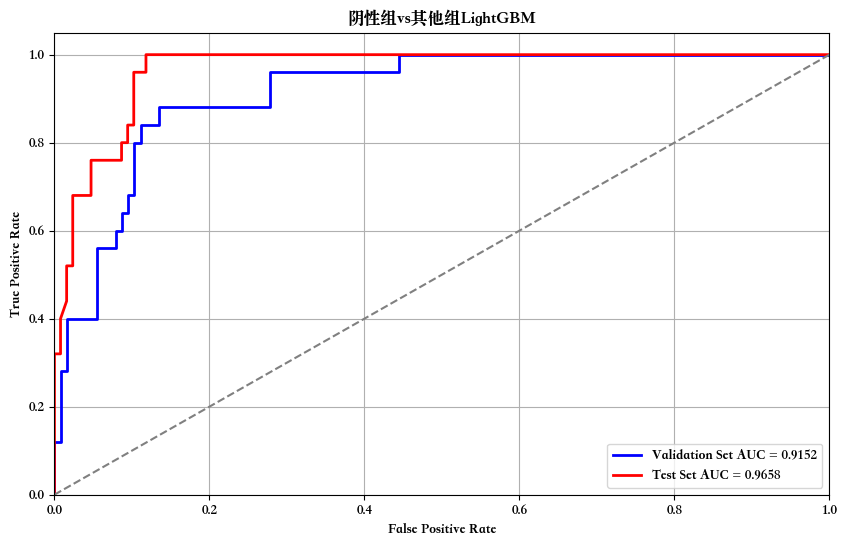

[0.8742, 0.5882, 0.8, 0.678, 0.9152, 0.9013, 0.625, 1.0, 0.7692, 0.9658]

In [9]:
#注册中文字体到matplotlib
font_path = "/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 预测验证集和测试集
y_val_pred = final_model.predict(X_val)
y_test_pred = final_model.predict(X_test)

# 预测验证集和测试集的概率（用于绘制 AUC 曲线）
y_val_prob = final_model.predict_proba(X_val)[:, 1]
y_test_prob = final_model.predict_proba(X_test)[:, 1]

# 计算准确率、精确率、召回率和F1分数
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

val_precision = precision_score(y_val, y_val_pred)
test_precision = precision_score(y_test, y_test_pred)

val_recall = recall_score(y_val, y_val_pred)
test_recall = recall_score(y_test, y_test_pred)

val_f1 = f1_score(y_val, y_val_pred)
test_f1 = f1_score(y_test, y_test_pred)

# 输出模型评估结果
print("Validation Set Performance:")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")
print(f"F1-Score: {val_f1:.4f}")

print("\nTest Set Performance:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# 绘制 ROC 曲线和 AUC
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

# 计算 AUC
roc_auc_val = auc(fpr_val, tpr_val)
roc_auc_test = auc(fpr_test, tpr_test)

# 绘制 ROC 曲线
plt.figure(figsize=(10, 6))
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label=f'Validation Set AUC = {roc_auc_val:.4f}')
plt.plot(fpr_test, tpr_test, color='red', lw=2, label=f'Test Set AUC = {roc_auc_test:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # 对角线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('阴性组vs其他组LightGBM')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



[round(val_accuracy,4),round(val_precision,4),round(val_recall,4),round(val_f1,4),round(roc_auc_val,4),round(test_accuracy,4),round(test_precision,4),round(test_recall,4),round(test_f1,4),round(roc_auc_test,4)]


===== SHAP 特征重要性 (柱状图):  =====


/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


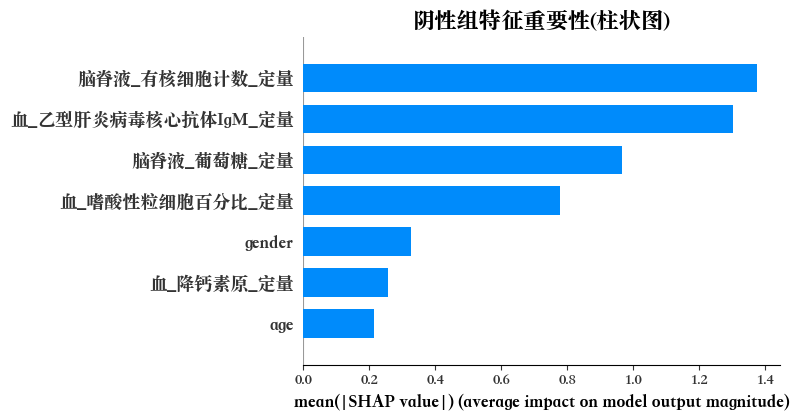


===== SHAP 特征分布 (蜂群图): =====


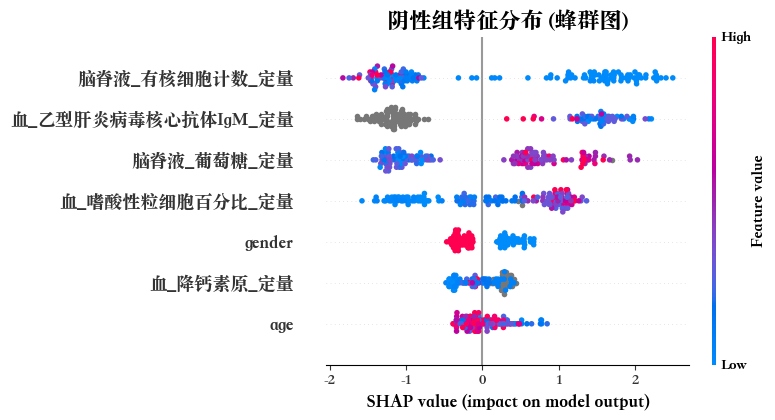

In [23]:

# ---------------- SHAP 分析 -----------------
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)
shap_matrix = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"\n===== SHAP 特征重要性 (柱状图):  =====")
plt.title("阴性组特征重要性(柱状图)", fontsize=16, fontweight='bold')
plt.tight_layout()
shap.summary_plot(shap_matrix, X_test, plot_type="bar", show=True)
plt.title("阴性组特征分布 (蜂群图)", fontsize=16, fontweight='bold')
plt.tight_layout()

print(f"\n===== SHAP 特征分布 (蜂群图): =====")
shap.summary_plot(shap_matrix, X_test, show=True)


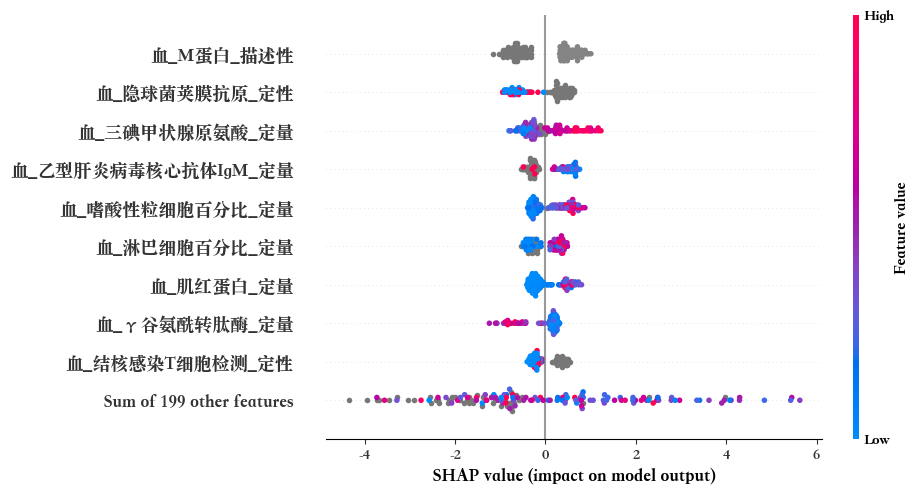

In [74]:
shap.plots.beeswarm(explainer(X_test))


In [56]:
import numpy as np

# 假设 shap_values 是你的SHAP值矩阵
# 检查该特征列的SHAP值是否真的全为0
feature_index = 109  # 替换为你的特征索引
shap_for_feature = shap_values[:, feature_index]

print(f"该特征SHAP值的唯一值: {np.unique(shap_for_feature)}")
print(f"该特征SHAP值的绝对值均值: {np.mean(np.abs(shap_for_feature))}")
print(f"该特征SHAP值全为0吗: {np.all(np.isclose(shap_for_feature, 0, atol=1e-10))}")

# 计算SHAP重要性（平均绝对SHAP值）
shap_importance = np.mean(np.abs(shap_values), axis=0)
print(f"所有特征的SHAP重要性: {shap_importance}")

# 找到最重要特征的索引
most_important_idx = np.argmax(shap_importance)
print(f"最重要特征的索引: {most_important_idx}")
print(f"该特征的SHAP重要性值: {shap_importance[most_important_idx]}")

该特征SHAP值的唯一值: [-1.16295915 -1.03204823 -1.01010519 -0.98675534 -0.94684174 -0.94517476
 -0.94293238 -0.91155715 -0.89354967 -0.86492691 -0.85405777 -0.84534609
 -0.84166958 -0.83591808 -0.8355005  -0.81463467 -0.80577271 -0.79311781
 -0.76608621 -0.7647784  -0.75782129 -0.74831716 -0.73899812 -0.73448076
 -0.72830581 -0.71480567 -0.71453366 -0.70656358 -0.69821557 -0.69431619
 -0.68678226 -0.68503104 -0.68155723 -0.677421   -0.67685571 -0.66895854
 -0.66224386 -0.64876175 -0.64605483 -0.64023993 -0.63385684 -0.63181136
 -0.63149387 -0.6281053  -0.62789465 -0.62009212 -0.61946775 -0.60969636
 -0.6094937  -0.60606395 -0.59014405 -0.5891096  -0.58016245 -0.57237591
 -0.56839425 -0.56558529 -0.55450684 -0.53278599 -0.52390612 -0.51589509
 -0.513367   -0.50378597 -0.50302951 -0.47356554 -0.4642274  -0.45986391
 -0.4594605  -0.4546473  -0.43532137 -0.43380124 -0.4258051  -0.40995742
 -0.40035835 -0.39885034 -0.32214105 -0.31760592 -0.31531976 -0.31191356
  0.31965634  0.3246902   0.32592791 

In [55]:
X_train.iloc[:,109]

179    0.0
633    NaN
658    NaN
276    0.0
576    0.0
      ... 
83     0.0
136    NaN
352    0.0
536    NaN
132    NaN
Name: 血_M蛋白_描述性, Length: 453, dtype: float64

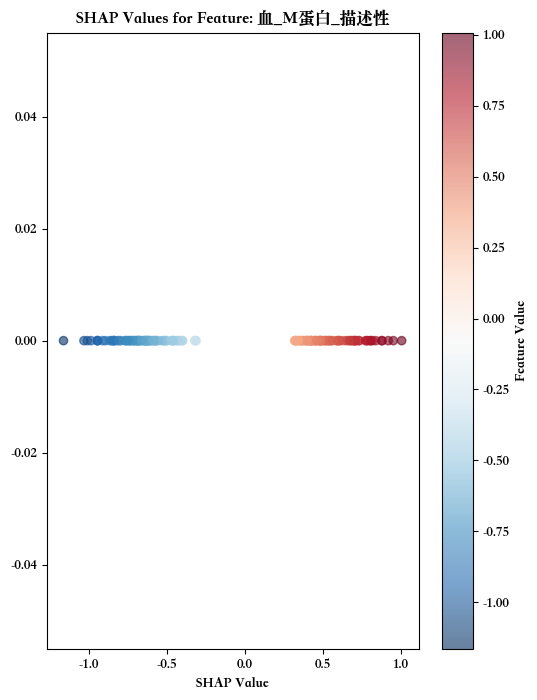

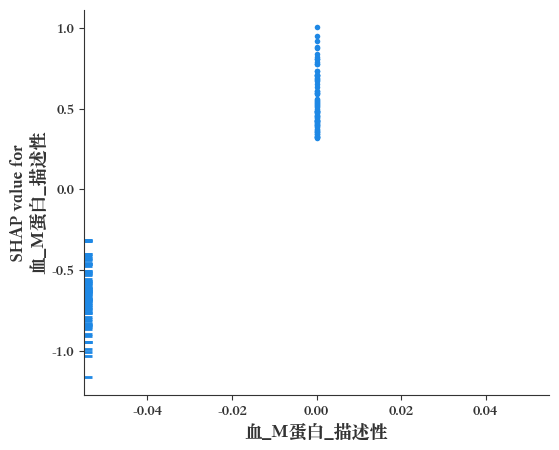

In [59]:

# # 假设你已经有了计算好的shap_values和特征数据集X
# # shap_values = explainer.shap_values(X)

# # 选择你关心的特征，例如特征名为 'feature_name' 或索引为 feature_index
# feature_name = 'your_feature_name'  # 请替换为你的特征名
# # 或者
# feature_index = 0  # 请替换为你的特征索引

# # 方法1：使用summary_plot并限制显示数量（虽然叫summary_plot，但设置max_display=1可以只显示一个特征）
# shap.summary_plot(shap_values, X, max_display=1, feature_names=X.columns)
# # 但请注意，summary_plot 的 `max_display` 参数用于限制显示的特征数量:cite[7]，将其设置为1可以只显示最重要的特征，但这可能无法直接指定任意特征。

# 方法2：更为直接的方法 - 为单个特征创建自定义图
# 获取该特征对应的SHAP值
feature_shap_values = shap_values[:, feature_index]  # 假设shap_values是二维数组

# 创建图形
plt.figure(figsize=(6, 8))
# 绘制该特征的SHAP值分布，我们可以用散点图来模拟蜂群图的效果
plt.scatter(feature_shap_values, [0] * len(feature_shap_values), alpha=0.6, c=feature_shap_values, cmap='RdBu_r')
plt.xlabel('SHAP Value')
plt.title(f'SHAP Values for Feature: 血_M蛋白_描述性')
plt.colorbar(label='Feature Value')
# 注意：这是一个简化的表示，真正的蜂群图在y轴方向会有堆叠效果以显示密度。

# 方法3：尝试使用依赖图（Dependence Plot），它可以展示单个特征与SHAP值之间的关系:cite[2]:cite[4]
shap.dependence_plot(feature_index, shap_values, X_test, interaction_index=None)
# 依赖图通常用于显示一个特征如何影响模型的预测（通过SHAP值），以及该特征与其他特征可能的交互作用:cite[2]:cite[4]。

/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Songti SC.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Songti SC.
  fig.canvas.print_figure(bytes_io, **kw)


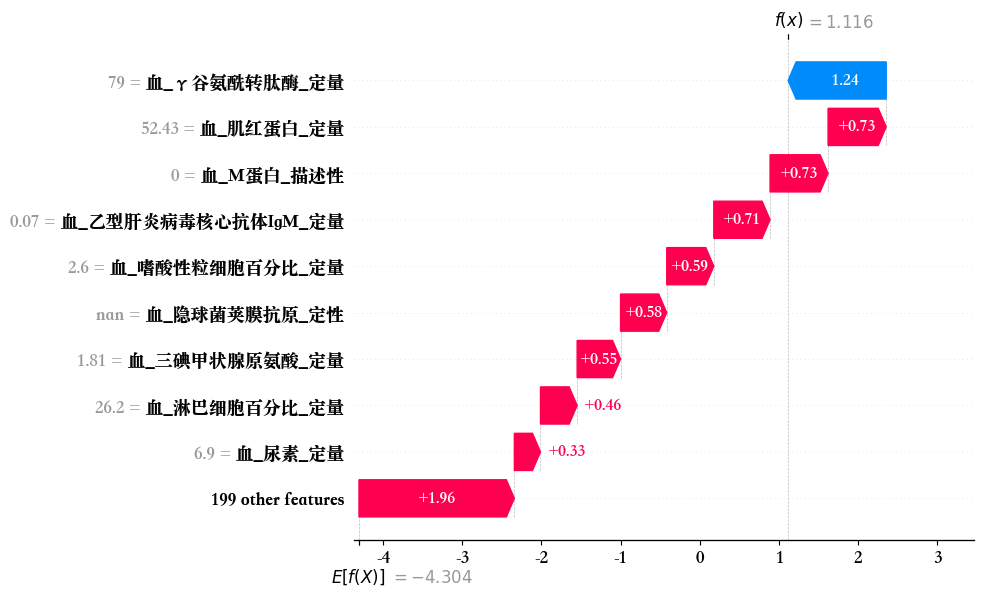

In [61]:
# 生成第一个样本的瀑布图
shap.plots.waterfall(shap.Explanation(values=shap_values[1], 
                                     base_values=explainer.expected_value, 
                                     data=X_test.iloc[1], 
                                     feature_names=X_test.columns))
plt.show()

In [68]:
filtered_df[filtered_df['血_M蛋白_描述性']==0].groupby(['分组'])['patientId'].count()

分组
0    97
1    39
2    65
3    44
4    58
5    16
6    69
Name: patientId, dtype: int64

In [69]:
filtered_df[filtered_df['血_M蛋白_描述性'].isna()].groupby(['分组'])['patientId'].count()

分组
0     27
1     25
2     42
3     18
4     53
5    132
6     71
Name: patientId, dtype: int64